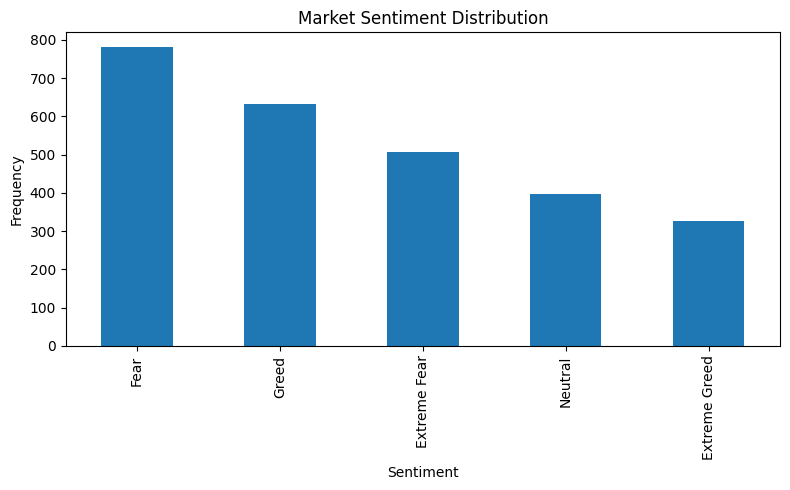

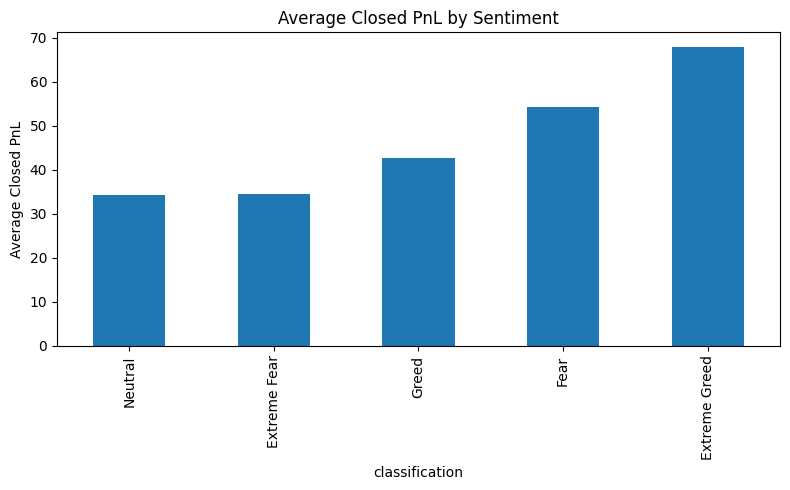

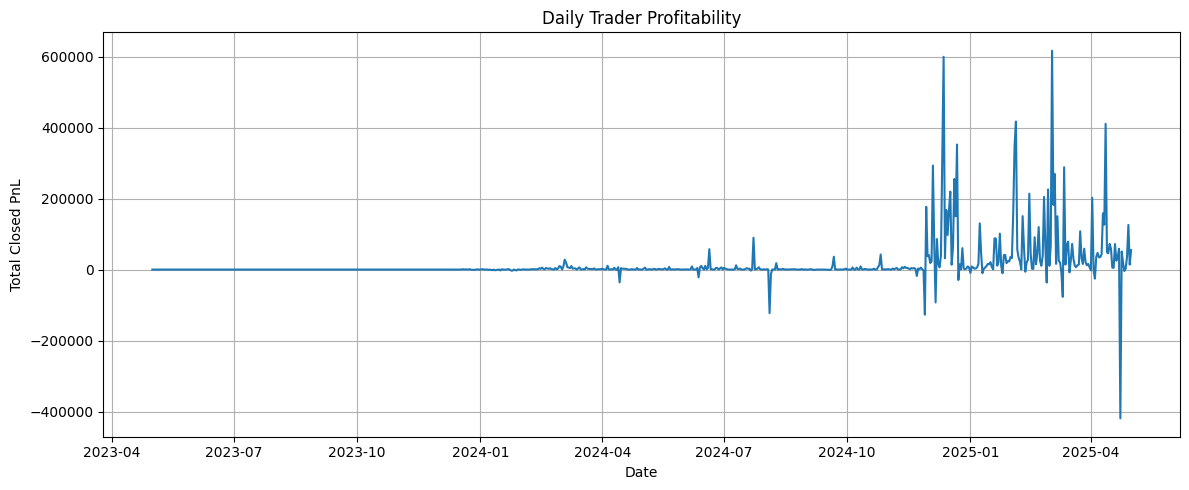

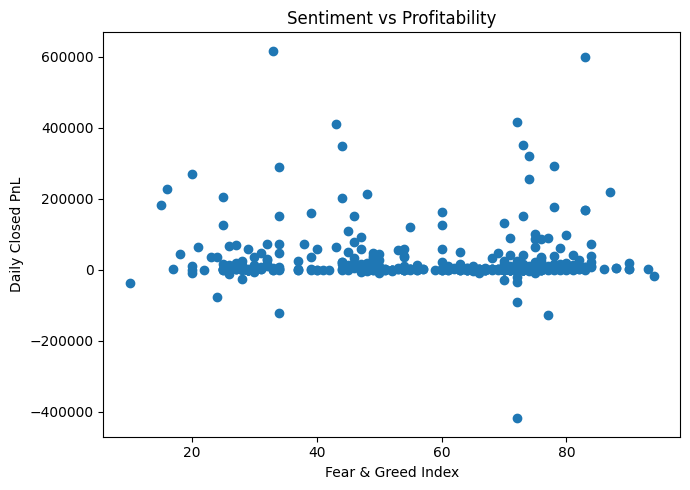

\nTOP CONSISTENT TRADERS\n
                                                total_pnl     avg_pnl  \
Account                                                                 
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4  379095.406711   38.319560   
0x2c229d22b100a7beb69122eed721cee9b24011dd  168658.004994   52.071011   
0xae5eacaf9c6b9111fd53034a602c192a04e082ed   67845.619531  120.507317   
0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0   72846.484272  174.691809   
0x6d6a4b953f202f8df5bed40692e7fd865318264a  108731.216772  111.519197   
0x430f09841d65beb3f27765503d0f850b8bce7713  416541.872341  336.735548   
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  677747.050643  155.589314   
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6   53496.247243  161.133275   
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f   14900.443047    9.557693   
0x420ab45e0bd8863569a5efbb9c05d91f40624641  199505.592732  520.902331   

                                                pnl_std  win_rate  \
Account                    

In [7]:
# =========================================================
# BITCOIN MARKET SENTIMENT VS TRADER PERFORMANCE ANALYSIS
# =========================================================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# LOAD DATASETS
# =========================================================

# Load Fear & Greed dataset
sentiment = pd.read_csv("fear_greed_index.csv")

# Load trader dataset
trades = pd.read_csv("historical_data.csv")

# =========================================================
# DATA CLEANING
# =========================================================

# Remove extra spaces from column names
sentiment.columns = sentiment.columns.str.strip()
trades.columns = trades.columns.str.strip()

# Convert date columns
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Convert trade timestamps
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

# Extract date from timestamp
trades['date'] = trades['Timestamp IST'].dt.floor('D')

# Convert numeric columns
numeric_cols = [
    'Closed PnL',
    'Fee',
    'Size USD',
    'Execution Price'
]

for col in numeric_cols:
    trades[col] = pd.to_numeric(
        trades[col],
        errors='coerce'
    )

# =========================================================
# MERGE DATASETS
# =========================================================

merged = pd.merge(
    trades,
    sentiment[['date', 'classification', 'value']],
    on='date',
    how='left'
)

# =========================================================
# FEATURE ENGINEERING
# =========================================================

# Profit/Loss flag
merged['is_profit'] = merged['Closed PnL'] > 0

# Risk-adjusted return
merged['risk_ratio'] = (
    merged['Closed PnL'] /
    (merged['Size USD'] + 1)
)

# High/Low leverage behavior
median_size = merged['Size USD'].median()

merged['trade_aggression'] = np.where(
    merged['Size USD'] > median_size,
    'High',
    'Low'
)

# =========================================================
# ANALYSIS 1: SENTIMENT DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,5))

sentiment['classification'] \
    .value_counts() \
    .plot(kind='bar')

plt.title('Market Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()

# =========================================================
# ANALYSIS 2: PNL BY SENTIMENT
# =========================================================

plt.figure(figsize=(8,5))

merged.groupby('classification')['Closed PnL'] \
    .mean() \
    .sort_values() \
    .plot(kind='bar')

plt.title('Average Closed PnL by Sentiment')
plt.ylabel('Average Closed PnL')

plt.tight_layout()
plt.savefig('pnl_by_sentiment.png')
plt.show()

# =========================================================
# ANALYSIS 3: DAILY PNL TREND
# =========================================================

daily_pnl = merged.groupby('date')['Closed PnL'] \
    .sum()

plt.figure(figsize=(12,5))

plt.plot(
    daily_pnl.index,
    daily_pnl.values
)

plt.title('Daily Trader Profitability')
plt.xlabel('Date')
plt.ylabel('Total Closed PnL')

plt.grid(True)

plt.tight_layout()
plt.savefig('daily_pnl_trend.png')
plt.show()

# =========================================================
# ANALYSIS 4: SENTIMENT VS PROFITABILITY
# =========================================================

daily_analysis = merged.groupby('date').agg({
    'Closed PnL': 'sum',
    'value': 'mean'
})

plt.figure(figsize=(7,5))

plt.scatter(
    daily_analysis['value'],
    daily_analysis['Closed PnL']
)

plt.xlabel('Fear & Greed Index')
plt.ylabel('Daily Closed PnL')

plt.title('Sentiment vs Profitability')

plt.tight_layout()
plt.savefig('sentiment_vs_profit.png')
plt.show()

# =========================================================
# TRADER CONSISTENCY ANALYSIS
# =========================================================

trader_stats = merged.groupby('Account').agg({
    'Closed PnL': ['sum', 'mean', 'std'],
    'is_profit': 'mean',
    'Size USD': 'sum'
})

# Rename columns
trader_stats.columns = [
    'total_pnl',
    'avg_pnl',
    'pnl_std',
    'win_rate',
    'total_volume'
]

# Consistency score
trader_stats['consistency_score'] = (
    trader_stats['avg_pnl'] *
    trader_stats['win_rate']
) / (trader_stats['pnl_std'] + 1)

# Top traders
top_traders = trader_stats.sort_values(
    'consistency_score',
    ascending=False
).head(10)

print("\\nTOP CONSISTENT TRADERS\\n")
print(top_traders)

# =========================================================
# FEAR VS GREED COMPARISON
# =========================================================

fear_data = merged[
    merged['classification']
    .str.contains('Fear', na=False)
]

greed_data = merged[
    merged['classification']
    .str.contains('Greed', na=False)
]

fear_avg = fear_data['Closed PnL'].mean()
greed_avg = greed_data['Closed PnL'].mean()

print("\\nFear Market Avg PnL:", fear_avg)
print("Greed Market Avg PnL:", greed_avg)

# =========================================================
# CORRELATION ANALYSIS
# =========================================================

correlation = daily_analysis['Closed PnL'].corr(
    daily_analysis['value']
)

print("\\nSentiment-Profit Correlation:", correlation)

# =========================================================
# FINAL INSIGHTS
# =========================================================

print("\\n========== FINAL INSIGHTS ==========")

if fear_avg > greed_avg:
    print(
        "- Traders performed better during Fear markets."
    )
else:
    print(
        "- Traders performed better during Greed markets."
    )

if correlation > 0:
    print(
        "- Positive correlation between sentiment and profitability."
    )
else:
    print(
        "- Negative correlation between sentiment and profitability."
    )

print(
    "- High market emotions significantly influence trader behavior."
)

print(
    "- Risk management is essential during volatile periods."
)

# =========================================================
# END OF PROJECT
# =========================================================